# 2장 2강: 시계열 데이터 모델링과 예측

## 실습 목표

이번 실습에서는 **Bike Sharing Demand** 데이터를 이용하여 시계열 예측의 기본 흐름을 연습합니다.

- 시간 순서를 유지하면서 **Train / Test 데이터**를 분리합니다.
- **AR, I, MA**가 무엇을 의미하는지 확인합니다.
- **ARIMA(2, 1, 1)** 모델을 학습합니다.
- Test 기간의 미래 값을 예측합니다.
- 실제값과 예측값을 비교합니다.
- **MAE, RMSE**를 이용해 예측 성능을 평가합니다.

> 이 실습에서는 2장 2강 교안에 나온 내용만 사용합니다.

## 실습 환경 / 데이터

- Python
- pandas
- matplotlib
- statsmodels
- scikit-learn
- 데이터: `Bike_Sharing_Demand.csv`

### 주요 컬럼

| 컬럼 | 의미 |
|---|---|
| `datetime` | 자전거 대여 기록 시각 |
| `casual` | 비등록 사용자 대여 수 |
| `registered` | 등록 사용자 대여 수 |
| `count` | 전체 자전거 대여 수 |

이번 강에서는 월별 대여량 `count`를 시계열로 사용합니다.

In [1]:
# 데이터 누수 : 예측 시점에는 사용할 수 없는 정보
# → 시험점수 데이터에 합격여부 컬럼이 있다면 ← 합격여부는 데이터 누수일 가능성이 있다.

# ARIMA
# 자기회귀 차수 p : 과거 시차의 범위를 정하는 값
# → 월별 ARIMA(2,0,0)이면 7월을 설명할 때 6월과 5월 매출을 사용하겠다는 의미

# 차분 지수 d : ARIMA 에서 차분을 몇 번 적용할지 나타내는 값
# → d = 차분x, d = 1(1차 차분), d = 2(2차 차분)

# 이동 평균 q = 과거 충격의 시차 범위를 정하는 값
# → 월별 q=2라면 7월을 설명할때 6월과 5월의 추정 오차를 반영하겠다.

# ARIMA : 차분 및 자기회귀 및 이동 평균 요소를 경험한 시계열 모델
# → ARIMA(2,1,1)은 매출을 한 번 차분한 뒤 최근 두 변화량과 직전 오차를 활용하여 모델링 하겠다는 뜻

## 실습 준비

다음 순서로 데이터를 준비합니다.

1. 데이터 불러오기
2. `datetime` 자료형 확인
3. 결측치 확인
4. `datetime`을 날짜/시간 자료형으로 변환
5. 시간 순서대로 정렬
6. 월별 대여량 `count` 준비

> 월별 집계 코드는 시계열 모델링을 위한 준비 코드로 제공됩니다.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

bike = pd.read_csv("Bike_Sharing_Demand.csv")

print("데이터 크기:", bike.shape)
display(bike.head())

print("\n[자료형]")
display(bike[["datetime", "count"]].dtypes.to_frame("dtype"))

print("\n[결측치]")
display(bike[["datetime", "count"]].isna().sum().to_frame("missing"))

데이터 크기: (10886, 12)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1



[자료형]


,dtype
datetime,str
count,int64



[결측치]


,missing
datetime,0
count,0


In [3]:
bike["datetime"] = pd.to_datetime(bike["datetime"])
bike = bike.sort_values("datetime").reset_index(drop=True)

bike["month"] = (
    bike["datetime"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

monthly = (
    bike.groupby("month", as_index=False)["count"]
    .sum()
)

monthly = monthly.set_index("month")

print("월별 데이터 개수:", len(monthly))
display(monthly.head())
display(monthly.tail())

월별 데이터 개수: 24


,count
month,
2011-01-01,23552
2011-02-01,32844
2011-03-01,38735
2011-04-01,50517
2011-05-01,79713


,count
month,
2012-08-01,130220
2012-09-01,133425
2012-10-01,127912
2012-11-01,105551
2012-12-01,98977


---

# 필수 1. 시간 순서를 유지한 Train / Test 분리

## 배경

시계열 데이터에서는 데이터를 무작위로 섞으면 미래 시점의 데이터가 Train에 포함될 수 있습니다.

따라서 **과거 데이터를 Train**, **그 이후 데이터를 Test**로 사용해야 합니다.

이번 실습에서는 월별 대여량의 **마지막 6개월을 Test 데이터**로 사용합니다.

## 문제 1. Train / Test 데이터를 분리하세요.

### 요구사항

1. `monthly`의 마지막 6개 행을 Test 데이터로 사용합니다.
2. 나머지 데이터를 Train 데이터로 사용합니다.
3. Train과 Test의 시작일과 종료일을 출력합니다.
4. Train과 Test를 같은 그래프에 표시합니다.

### 확인 포인트

- 시간 순서를 유지했는가?
- Test 데이터가 Train 데이터보다 뒤의 기간인가?
- 무작위 분리를 사용하지 않았는가?

Train : 2011-01 ~ 2012-06  (18개월)
Test  : 2012-07 ~ 2012-12  (6개월)
시간 순서 유지 확인 : True


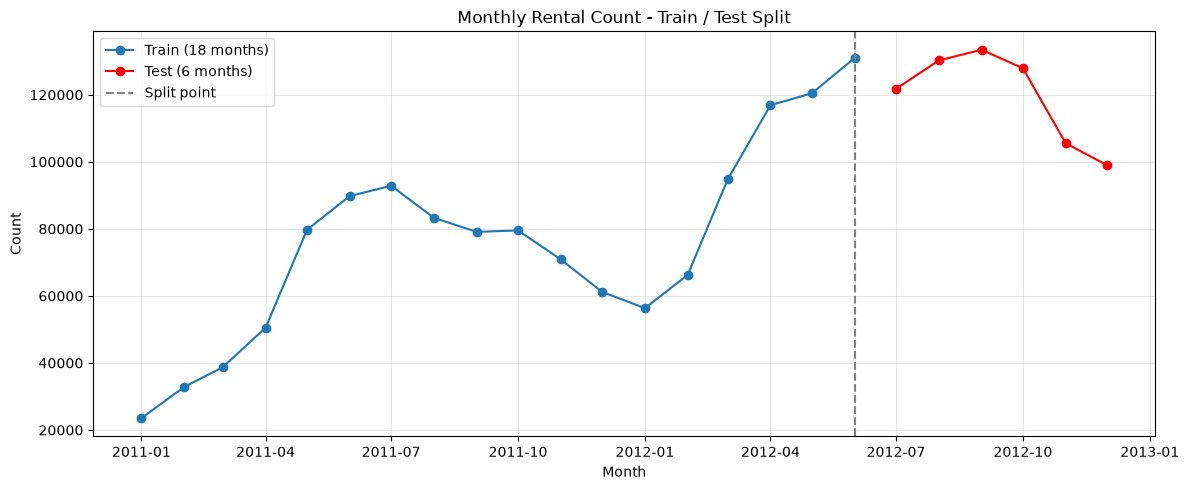

In [4]:
# ===== 요구사항 1·2. Train / Test 분리 =====
train = monthly.iloc[:-6]
test  = monthly.iloc[-6:]

# ===== 요구사항 3. 기간 출력 =====
print(f"Train : {train.index.min():%Y-%m} ~ {train.index.max():%Y-%m}  ({len(train)}개월)")
print(f"Test  : {test.index.min():%Y-%m} ~ {test.index.max():%Y-%m}  ({len(test)}개월)")
print(f"시간 순서 유지 확인 : {train.index.max() < test.index.min()}")

# ===== 요구사항 4. 같은 그래프에 표시 =====
plt.figure(figsize=(12, 5))
plt.plot(train.index, train["count"], marker="o", label=f"Train ({len(train)} months)")
plt.plot(test.index,  test["count"],  marker="o", color="red", label=f"Test ({len(test)} months)")
plt.axvline(train.index.max(), color="gray", linestyle="--", label="Split point")
plt.title("Monthly Rental Count - Train / Test Split")
plt.xlabel("Month"); plt.ylabel("Count")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

예측 시점은 2012년 6월까지를 알고있는 상태로 가정  
2012년 12월 까지의 데이터가 존재하더라도 시계열에서 예측 시점에는 7월~12월 데이터를 모르는 것처럼 남겨둔다.  

18개월은 18개의 관측값일 뿐 18개월 치의 시간별 표본을 의미하지는 않음  
해석 : 월별 관측 합계(총 기간) 24개월중 앞서 18개월을 TRAIN, 마지막 6개월을 TEST로 분리  
-> 2011년 1월~2012년 6월까지의 정보를 토대로 2012년 7월부터 2012년 12월까지를 예측하겠다.  

### Q1. 시계열 데이터에서 무작위로 Train / Test를 분리하면 안 되는 이유는 무엇인가요?

**답변:**  
시계열 데이터는 순서가 매우 중요하다  
무작위로 섞게되면 시간의 흐름을 알수가 없고 미래 시점이 train에 포함될 수 있다.


---

# 필수 2. ARIMA 모델 학습과 미래 값 예측

## 배경

ARIMA는 다음 세 가지 요소로 구성됩니다.

- **AR(p)**: 과거의 실제 값을 몇 개 사용할 것인가?
- **I(d)**: 차분을 몇 번 적용할 것인가?
- **MA(q)**: 과거의 예측 오차를 몇 개 사용할 것인가?

이번 실습에서는 교안과 동일하게 `ARIMA(2, 1, 1)`을 사용합니다.

## 문제 1. ARIMA(2, 1, 1)의 의미를 설명하세요.

### 요구사항

다음 세 값을 각각 설명합니다.

- `p = 2`
- `d = 1`
- `q = 1`

### Q2. 각각 무엇을 의미하나요?

**답변:**  
p=2 : 1차 차분한 시계열의 과거 2개의 시점값을 활용  
d=1 : 1차 차분을 적용  
q=1 : 1차 차분한 시계열의 직전 1개의 시점의 예측 오차를 활용

## 문제 2. Train 데이터로 ARIMA 모델을 학습하세요.

### 요구사항

1. `statsmodels.tsa.arima.model`에서 `ARIMA`를 불러옵니다.
2. Train 데이터의 `count`를 사용합니다.
3. `order=(2, 1, 1)`을 지정합니다.
4. `fit()`으로 모델을 학습합니다.

### 확인 포인트

- Test 데이터를 학습에 사용하지 않았는가?
- `order=(p, d, q)`의 순서를 알고 있는가?

In [5]:
# TODO
# ARIMA(2, 1, 1) 모델을 생성하고 학습하세요.

from statsmodels.tsa.arima.model import ARIMA

# ===== 모델 생성 및 학습 =====
model = ARIMA(train["count"], order=(2, 1, 1))
fitted = model.fit()

# ===== 학습 결과 확인 =====
print(fitted.summary())
print(f"\nAIC : {fitted.aic:.4f}")

# ===== Test 기간 예측 =====
forecast = fitted.forecast(steps=len(test))
print("\n=== 예측 결과 ===")
print(forecast.round(1))

                               SARIMAX Results                                
Dep. Variable:                  count   No. Observations:                   18
Model:                 ARIMA(2, 1, 1)   Log Likelihood                -180.476
Date:                Tue, 06 Oct 2026   AIC                            368.953
Time:                        12:23:08   BIC                            372.285
Sample:                    01-01-2011   HQIC                           369.284
                         - 06-01-2012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5770      0.932      0.619      0.536      -1.249       2.403
ar.L2         -0.1038      0.541     -0.192      0.848      -1.165       0.957
ma.L1          0.2235      1.001      0.223      0.8

c:\Users\sjh96\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\sjh96\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\sjh96\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [6]:
# [상단 기본 정보]
# Dep. Variable -> count : 학습 대상으로 사용한 월 별 관측 대여량 합계
# No. Observations -> 18 : 입력한 train의 관측값 계수
# model -> arima(2,1,1) : 지정된 p,d,q의 구조
# sample -> 2011.01~2012.06 : 학습에 사용한 기간 범위
# Log Likelihood -> -180 : 추정한 모형이 관측자료를 설명하는 우도(정도)를 로그로 요약한 값
# AIC / BIC / HOIC -> 368, 372, 369 : 적합도와 모형 복잡도를 함께 고려하는 정도

# [중간 기본 정보]
# ar. L1 -> 0.577 : 직전 시점의 차분값에 적용되는 자기회귀 가중치
# ar. L2 -> -0.103 : 두 시점 전 차분값에 적용되는 자기회귀 가중치
# ma. L1 -> 약 8.347 * 10의 7제곱 : 모형에서 추정한 오차의 분산
# sigma2 -> 8.347*10의 7제곱 : 모형에서 추정한 오차의 분산

# ****
# coef -> 추정계수 : 모형에 들어가는 가중치나 분산 추정값
# std err -> 추정 표준오차 : 계수 추정 불확실성에 관한 값
# z -> 계수, 표준 오차에 의한 검정통계량 : 적절한 추론 조건에서 계수가 0이라는 가설을 판단하는데 사용 오차가 
# p > -> z:
# [0.025, 0.975] -> 계수 명목상 95%의 신뢰구간

# ar.L1          0.5770      0.932      0.619      0.536      -1.249       2.403
# ar.L1 해석 방법 : 계수: 0.57, 표준편차:0.93, z:0.619, p-value:0.536, 95% 신뢰구간: -1.249 ~ 2.403
# 해석 : 추정 계수가 양수인 것으로 확인되지만 표준오차가 계수보다 큰 경우, 신뢰구간도 음수에서부터 양수로 비교적 넓게 분포되어있음
# 따라서 직전 변화량의 양의 가중치가 추정되어있음
# -> 한줄 : 이 데이터 예측하기 어려움


# [하단 기본 정보]
# L-jing-Box (L1) / Prob(Q) : Q약 0.00 / 0.95 → 표시된 1시차의 잔차 자기상관에 대한 진단
# → 0.95는 0.05보다 크기 때문에 귀무가설을 기각하지 못함
# → 귀무가설은 검사한 시차까지 잔차의 자기상관이 없다 <- 이를 기각하지 못함
# → 한줄 : 자기상관을 확인할 수 없다.

# Jarque-Bera (JB) / Prob(JB) : 0.01 / 0.67 → 잔차의 정규성에 대한 진단
# → 0.67은 0.05보다 크기 때문에 귀무가설을 기각하지 못함
# → 귀무가설은 잔차가 정규분포를 따른다 <- 이를 기각하지 못함


# Heteroskedasticity (H) / Prob(H) : 0.07 → 오차의 크기가 시간에 따라 달라지는지?
# 초반에는 오차가 +-10 정도 / 후반에는 +-100정도로 시간이 지남에 따라 오차의 불확실성이 커짐

# Skew : 0.47 → 오차의 분포가 어느 방향으로 대칭 또는 비대칭을 이루고 있나요?
# skew를 왜도라고 부르는데 0에 가까울수록 좌우 대칭모양이다.
# 지금은 0.41로 양의 대칭을 보이는 즉 양수방향으로 꼬리가 긴 분포

# Kurtosis : 2.30 → 3을 기준으로 정규분포에서 얼마나 극단적인 값들이 분포가 되어있을까?
# kurtosis를 첨도라고 부르는데, 이 모델링 기준에서는 첨도가 3인데
# 3을 기준으로 크거나 작은 극단값들이 얼마나 있는지

## 문제 3. Test 기간만큼 미래 값을 예측하세요.

### 요구사항

1. `forecast()`를 사용합니다.
2. `steps=len(test)`로 Test 기간과 같은 개수만큼 예측합니다.
3. 예측값의 인덱스를 Test 데이터의 인덱스와 동일하게 설정합니다.
4. `actual`, `predicted` 컬럼을 가진 DataFrame을 만듭니다.
5. 실제값과 예측값을 같은 그래프에 표시합니다.

### 확인 포인트

- Train 마지막 시점 이후의 값을 예측했는가?
- Test 길이와 예측값 개수가 같은가?
- Actual과 Predicted를 구분했는가?

            actual  predicted    error
month                                 
2012-07-01  121769   139405.9 -17636.9
2012-08-01  130220   143188.7 -12968.7
2012-09-01  133425   144494.5 -11069.5
2012-10-01  127912   144855.3 -16943.3
2012-11-01  105551   144928.0 -39377.0
2012-12-01   98977   144932.5 -45955.5

Test 길이 : 6 / 예측 개수 : 6 / 일치 : True
Train 마지막 : 2012-06 / 예측 시작 : 2012-07

MAE  : 23,991.8
RMSE : 27,541.8


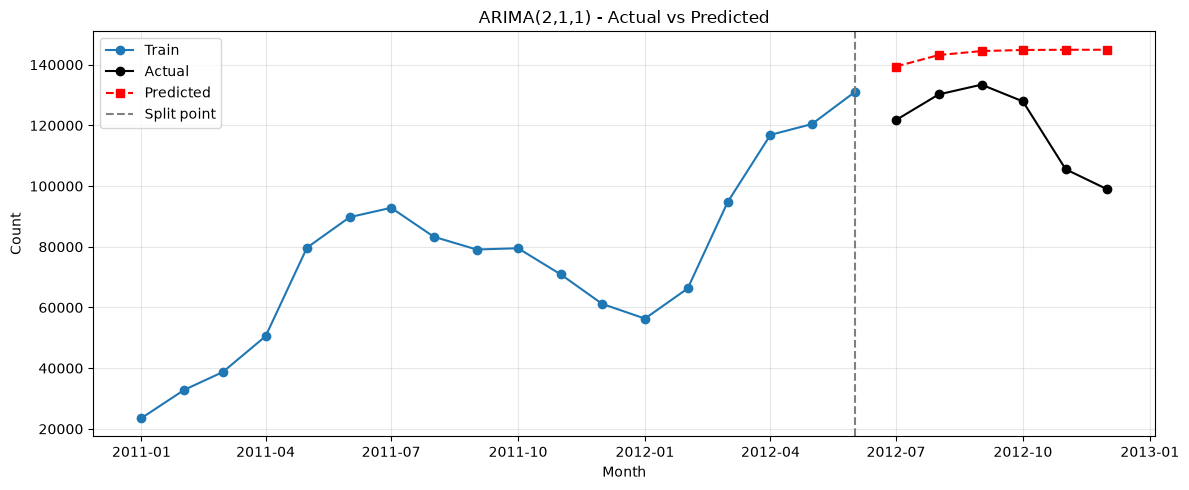

In [7]:
# TODO
# Test 기간만큼 예측하고 Actual / Predicted를 비교하세요.
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ===== 요구사항 1·2. Test 기간만큼 예측 =====
forecast = fitted.forecast(steps=len(test))

# ===== 요구사항 3. 인덱스를 Test와 동일하게 =====
forecast.index = test.index

# ===== 요구사항 4. actual / predicted DataFrame =====
result = pd.DataFrame({
    "actual":    test["count"],
    "predicted": forecast
})
result["error"] = result["actual"] - result["predicted"]

print(result.round(1))

# --- 확인 포인트 검증 ---
print("\nTest 길이 :", len(test), "/ 예측 개수 :", len(forecast),
      "/ 일치 :", len(test) == len(forecast))
print("Train 마지막 :", train.index.max().strftime("%Y-%m"),
      "/ 예측 시작 :", forecast.index.min().strftime("%Y-%m"))

# --- 오차 지표 ---
mae  = mean_absolute_error(result["actual"], result["predicted"])
rmse = np.sqrt(mean_squared_error(result["actual"], result["predicted"]))
print(f"\nMAE  : {mae:,.1f}")
print(f"RMSE : {rmse:,.1f}")

# ===== 요구사항 5. 같은 그래프에 표시 =====
plt.figure(figsize=(12, 5))
plt.plot(train.index, train["count"], marker="o", label="Train")
plt.plot(result.index, result["actual"], marker="o", color="black", label="Actual")
plt.plot(result.index, result["predicted"], marker="s", linestyle="--",
         color="red", label="Predicted")
plt.axvline(train.index.max(), color="gray", linestyle="--", label="Split point")
plt.title("ARIMA(2,1,1) - Actual vs Predicted")
plt.xlabel("Month"); plt.ylabel("Count")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()


2012-07 : 실제 관측 합계 : 121,769 / 예측 합계 : 139,405 -> 약 17,636건 과대 예측  
2012-08 : 실제 관측 합계 : 130,220 / 예측 합계 : 143,188 -> 약 12,969건 과대 예측  
2012-09 : 실제 관측 합계 : 133,425 / 예측 합계 : 144,494 -> 약 11,069건 과대 예측  
-> 과대 예측하는 경향이 보임  

- 해석 : 2011년 1월~2012년 6월까지 18개월을 학습하여 향후 6개월을 예측했다.  
-> 예측값은 모든 test 월에서 실제보다 높게 측정되었으며 오차가 큰 편이었다.  
-> 정확하게 해석하기 위해서 추가적인 성능평가도 함께 확인해야한다.  

### Q3. `steps=len(test)`는 무엇을 의미하나요?

**답변:**  
`test 데이터와 동일한 개수의 미래 시점을 예측한다는 의미`  
-> 이번 모델링에서는 향후 6개월임

### Q4. Actual과 Predicted는 각각 무엇을 의미하나요?

**답변:**  
Actual : test 기간에 실제로 관측된 자전거 대여량  
Predicted : train 데이터만 학습한 arima 모델이 주어진 test 기간에 대해 예측한 값

---

# 과제 1. 정상성 진단을 반영한 ARIMA 예측과 예측 신뢰도 평가

## 배경

필수 1의 Train/Test 분리는 유지합니다. 과제에서는 Train 데이터의 정상성을 먼저 진단한 뒤 ARIMA의 차분 차수 d를 선택하여 모델을 다시 학습합니다. MAE·RMSE와 함께 **95% 예측 구간의 하한·상한**을 실제값과 비교합니다.

## 요구사항

1. 필수 1에서 만든 `train`, `test`를 사용합니다. 정상성 진단과 모델 설정에는 Train만 사용합니다.
2. Train의 `count`와 최근 3개 관측값의 이동평균을 그래프로 확인합니다. 원본에 ADF Test를 수행하고 검정통계량과 p-value를 출력합니다. 짧은 월별 자료이므로 이번 과제의 검정 설정은 `maxlag=1, regression="c", autolag="AIC"`로 통일합니다.
3. 유의수준 0.05에서 원본의 단위근 귀무가설을 기각하면 d=0을 우선 검토합니다. 기각하지 못하면 1차 차분한 Train에 같은 설정으로 ADF Test를 다시 수행하고 차분 그래프를 확인합니다. 차분 후 기각하면 d=1을 선택합니다. 차분 후에도 기각하지 못하면 추가 진단이 필요함을 명시하고, 이번 과제에서는 d=1을 잠정 설정하여 예측 과정과 한계를 함께 평가합니다. 선택 근거에 그래프 해석도 포함합니다.
4. **차분하지 않은 Train의 원본 `count`**를 `ARIMA(order=(2, d, 1))`에 전달해 학습합니다. 차분은 모델 내부에서 처리하므로 차분 데이터에 d=1을 다시 적용하지 않습니다. 필수 2의 모델·결과와 구분하여 과제용 변수를 사용합니다.
5. `get_forecast(steps=len(test))`로 Test 기간의 예측값과 95% 예측 구간을 구합니다. `predicted_mean`과 `conf_int(alpha=0.05)`를 활용합니다.
6. Test 날짜에 맞춰 `actual`, `predicted`, `lower_95`, `upper_95`를 가진 `task_result`를 만들고 출력합니다.
7. 과제 모델의 MAE·RMSE를 계산하고 의미를 설명합니다.
8. 실제값·예측값·95% 예측 구간을 같은 그래프에 표시합니다. 시점별 구간 폭과 실제값의 구간 포함 여부를 표에 추가하고, 구간 밖인 시점을 확인합니다.
9. 실제값과 구간의 비교 및 구간 폭을 근거로 예측 신뢰도를 해석합니다. 신뢰도가 낮다고 판단한 구간의 가능한 원인 또는 모델의 한계를 한 가지 이상 설명합니다. 구간 밖인 시점이 없더라도 구간 폭과 자료의 한계를 검토합니다.

> Test는 최종 평가에만 사용합니다. Test 결과를 보고 d나 다른 모델 설정을 다시 선택하지 않습니다. 월별 값은 제공된 CSV의 관측값 합계이며, 월 전체 날짜가 없으면 완전한 월간 총수요로 해석하지 않습니다.

### 확인 포인트

- Train만으로 정상성을 진단하고 d 선택 근거를 제시했는가?
- 1차 차분 후에도 귀무가설을 기각하지 못한 경우 잠정 모델의 한계를 밝혔는가?
- 원본 Train을 모델에 입력하여 이중 차분을 피했는가?
- MAE·RMSE와 실제값·예측값·예측 구간을 함께 확인했는가?
- 구간 밖 실제값과 구간 폭을 근거로 예측 신뢰도와 한계를 설명했는가?
- Q5~Q9에 모두 답했는가?


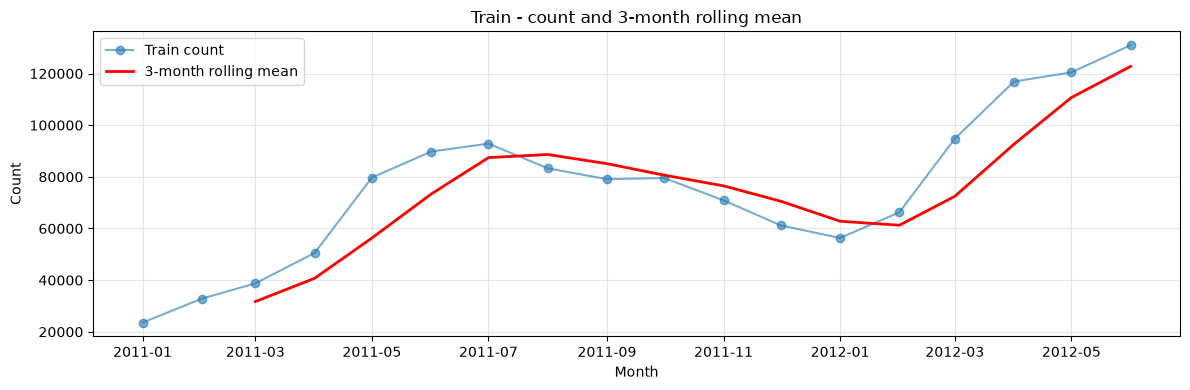

3개월 이동 평균 month
2011-03-01     31710.0
2011-04-01     40699.0
2011-05-01     56322.0
2011-06-01     73335.0
2011-07-01     87446.0
2011-08-01     88640.0
2011-09-01     85083.0
2011-10-01     80641.0
2011-11-01     76505.0
2011-12-01     70531.0
2012-01-01     62801.0
2012-02-01     61261.0
2012-03-01     72456.0
2012-04-01     92640.0
2012-05-01    110695.0
2012-06-01    122759.0
Name: count, dtype: float64
[Train 원본 ADF]
  ADF Statistic : -1.5711
  p-value       : 4.9812e-01
  판단          : 기각 못함 -> 비정상

[Train 1차 차분 ADF]
  ADF Statistic : -1.9814
  p-value       : 2.9478e-01
  판단          : 기각 못함 -> 추가 진단 필요


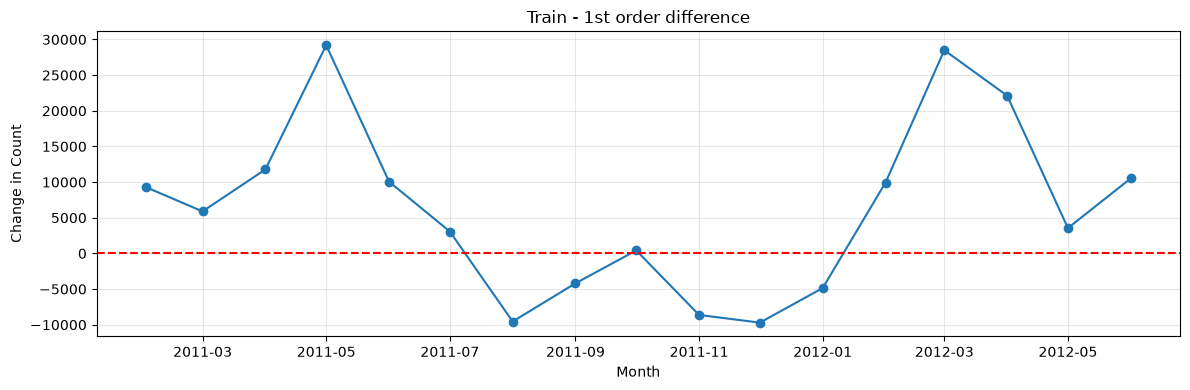


>>> 선택된 d = 1   (차분 후에도 기각하지 못함 -> 추가 진단 필요, d=1 잠정 설정)
1차 차분
month
2011-02-01     9292.0
2011-03-01     5891.0
2011-04-01    11782.0
2011-05-01    29196.0
2011-06-01    10063.0
2011-07-01     3072.0
2011-08-01    -9552.0
2011-09-01    -4192.0
2011-10-01      418.0
2011-11-01    -8633.0
2011-12-01    -9706.0
2012-01-01    -4851.0
2012-02-01     9937.0
2012-03-01    28497.0
2012-04-01    22119.0
2012-05-01     3549.0
2012-06-01    10523.0
Name: count, dtype: float64

과제 모델 : ARIMA(2, 1, 1)   AIC = 368.9525

=== task_result ===
            actual  predicted  lower_95  upper_95  interval_width  in_interval    error  error_pct
month                                                                                             
2012-07-01  121769   139405.9  121498.8  157313.0         35814.2         True -17636.9       14.5
2012-08-01  130220   143188.7  106308.1  180069.4         73761.3         True -12968.7       10.0
2012-09-01  133425   144494.5   91068.7  197920.3        106851.6      

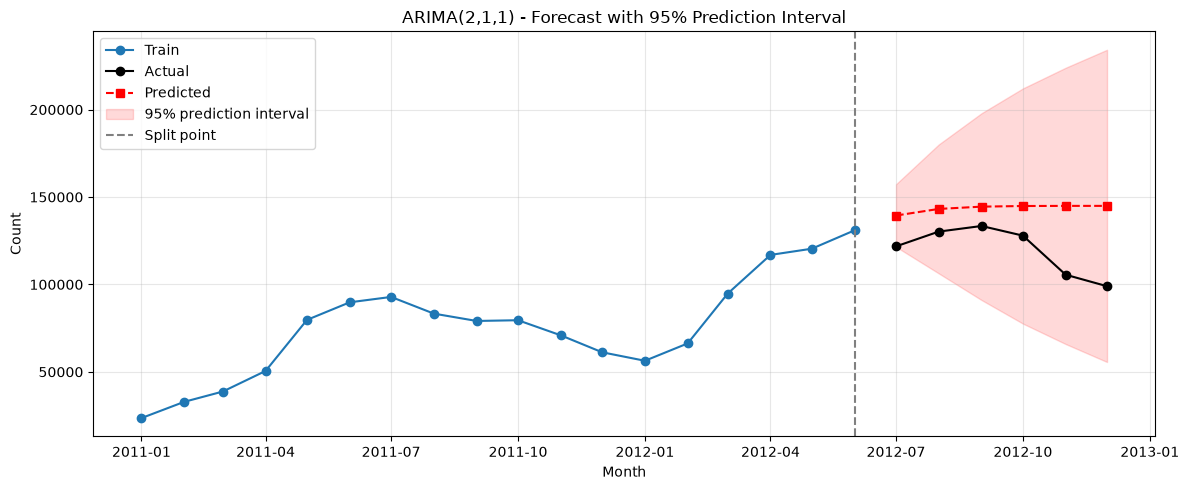

In [13]:
# TODO
# Train 정상성 진단 → d 선택 → 과제용 ARIMA 학습
# → 점예측·95% 예측 구간 → MAE·RMSE → 신뢰도 및 한계 해석

import warnings
warnings.filterwarnings("ignore")
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 과제 전용 ADF 설정 (요구사항 2)
ADF_KW = dict(maxlag=1, regression="c", autolag="AIC")


# ===== 요구사항 2. Train 이동평균(3개) + 원본 ADF Test =====
train_ma3 = train["count"].rolling(window=3).mean()

plt.figure(figsize=(12, 4))
plt.plot(train.index, train["count"], marker="o", alpha=0.6, label="Train count")
plt.plot(train.index, train_ma3, color="red", linewidth=2, label="3-month rolling mean")
plt.title("Train - count and 3-month rolling mean")
plt.xlabel("Month"); plt.ylabel("Count")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

adf_orig = adfuller(train["count"], **ADF_KW)
print(f"3개월 이동 평균", train_ma3.dropna().round(0))
print("[Train 원본 ADF]")
print(f"  ADF Statistic : {adf_orig[0]:.4f}")
print(f"  p-value       : {adf_orig[1]:.4e}")
print("  판단          :", "기각 -> 정상" if adf_orig[1] < 0.05 else "기각 못함 -> 비정상")


# ===== 요구사항 3. d 선택 =====
if adf_orig[1] < 0.05:
    d = 0
    note = "원본에서 귀무가설을 기각하여 d=0 선택"
else:
    train_diff = train["count"].diff().dropna()
    adf_diff = adfuller(train_diff, **ADF_KW)

    print("\n[Train 1차 차분 ADF]")
    print(f"  ADF Statistic : {adf_diff[0]:.4f}")
    print(f"  p-value       : {adf_diff[1]:.4e}")
    print("  판단          :", "기각 -> 정상" if adf_diff[1] < 0.05 else "기각 못함 -> 추가 진단 필요")

    plt.figure(figsize=(12, 4))
    plt.plot(train_diff.index, train_diff.values, marker="o")
    plt.axhline(0, color="red", linestyle="--")
    plt.title("Train - 1st order difference")
    plt.xlabel("Month"); plt.ylabel("Change in Count")
    plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

    if adf_diff[1] < 0.05:
        d = 1
        note = "1차 차분 후 귀무가설을 기각하여 d=1 선택"
    else:
        d = 1
        note = "차분 후에도 기각하지 못함 -> 추가 진단 필요, d=1 잠정 설정"

print(f"\n>>> 선택된 d = {d}   ({note})")
train_diff = train["count"].diff().dropna()
print("1차 차분")
print(train_diff.round(0))


# ===== 요구사항 4. 원본 Train 으로 학습 (이중 차분 방지) =====
task_model  = ARIMA(train["count"], order=(2, d, 1))   # ← 차분 안 한 원본
task_fitted = task_model.fit()
print(f"\n과제 모델 : ARIMA(2, {d}, 1)   AIC = {task_fitted.aic:.4f}")


# ===== 요구사항 5·6. 점예측 + 95% 예측 구간 =====
task_fc   = task_fitted.get_forecast(steps=len(test))
task_pred = task_fc.predicted_mean
task_ci   = task_fc.conf_int(alpha=0.05)

task_pred.index = test.index
task_ci.index   = test.index

task_result = pd.DataFrame({
    "actual":    test["count"],
    "predicted": task_pred,
    "lower_95":  task_ci.iloc[:, 0],
    "upper_95":  task_ci.iloc[:, 1],
})

# ===== 요구사항 8. 구간 폭 / 포함 여부 =====
task_result["interval_width"] = task_result["upper_95"] - task_result["lower_95"]
task_result["in_interval"] = (
    (task_result["actual"] >= task_result["lower_95"]) &
    (task_result["actual"] <= task_result["upper_95"])
)
task_result["error"] = task_result["actual"] - task_result["predicted"]
task_result["error_pct"] = (task_result["error"].abs() / task_result["actual"] * 100).round(1)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", None)

print("\n=== task_result ===")
print(task_result.round(1))


# ===== 요구사항 7. MAE / RMSE =====
mae  = mean_absolute_error(task_result["actual"], task_result["predicted"])
rmse = mean_squared_error(task_result["actual"], task_result["predicted"]) ** 0.5

print(f"\nMAE  : {mae:,.1f}")
print(f"RMSE : {rmse:,.1f}")
print(f"실제 평균 대비 MAE : {mae / task_result['actual'].mean() * 100:.1f}%")
print(f"RMSE / MAE : {rmse / mae:.3f}")

print(f"\n구간 안 : {task_result['in_interval'].sum()} / {len(task_result)}")
out = task_result[~task_result["in_interval"]]
print("구간 밖 시점 :", "없음" if out.empty else list(out.index.strftime('%Y-%m')))
print(f"구간 폭 : {task_result['interval_width'].iloc[0]:,.0f} -> "
      f"{task_result['interval_width'].iloc[-1]:,.0f} "
      f"({task_result['interval_width'].iloc[-1] / task_result['interval_width'].iloc[0]:.2f}배)")


# ===== 요구사항 8. 그래프 =====
plt.figure(figsize=(12, 5))
plt.plot(train.index, train["count"], marker="o", label="Train")
plt.plot(task_result.index, task_result["actual"], marker="o", color="black", label="Actual")
plt.plot(task_result.index, task_result["predicted"], marker="s", linestyle="--",
         color="red", label="Predicted")
plt.fill_between(task_result.index, task_result["lower_95"], task_result["upper_95"],
                 color="red", alpha=0.15, label="95% prediction interval")
plt.axvline(train.index.max(), color="gray", linestyle="--", label="Split point")
plt.title(f"ARIMA(2,{d},1) - Forecast with 95% Prediction Interval")
plt.xlabel("Month"); plt.ylabel("Count")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


### Q5. MAE는 어떻게 해석할 수 있나요?

**답변:**  
- 예측값과 실제값 차이의 절댓값을 평균한 값 : 23,991.8  
-> 예측이 실제값에서 평균적으로 23,991.8건 정도 차이가 난다는 뜻으로 해석  
- task_result 에서 6개 시점 모두 predicted(예측)가 actual(실제)보다 높게 예측했으나  
MAE는 절댓값을 취해 오차의 방향이 사라지므로 예측이 높았는지 낮았는지 알 수 없음

### Q6. RMSE가 MAE보다 큰 오차에 더 민감한 이유는 무엇인가요?

**답변:**  
- MAE는 오차를 그대로 평균하지만, RMSE는 오차를 제곱하기 때문에 큰 오차에 더 민감  
- 12월 오차(45,956)는 9월 오차(11,070)의 4.15배 -> 제곱하면 17.24배로 커짐  
-> MAE 는 23,991.8, RMSE 는 27,541.8로 큰 오차가 더 크게 반영되어 RMSE가 더 크게 산출됨

### Q7. Train 데이터의 ADF 검정 결과와 그래프를 근거로 d를 어떻게 선택했나요? 정상성 판단에 남아 있는 한계는 무엇인가요?

**답변:**  
원본 Train : 검정통계량: -1.5711, p-value: 4.9812e-01로 유의수준 0.05 보다 크기 때문에 귀무가설을 기각하지 못함  
-> 정상성을 만족한다고 볼 수 없기 때문에 `d=0 은 채택하지 않고 1차 차분`  

그래프에서도 2011년 3월 31,710 에서 2012년 6월 122,759로 우상향하는 trend를 보였으며,  
중간의 2011년 8월 88,640 에서 2012년 2월 61,261로 하락했다가 다시 상승하는 구간도 나타남.  
평균 수준이 시간에 따라 계속 변하고 있어 정상성 조건을 만족한다고 볼 수 없음.  

**1차 차분 Train**: 같은 설정으로 재검정한 결과 검정통계량 : -1.9814, p-value : 2.9478e-01로 유의수준 0.05 보다 크기 때문에  
-> 차분 후에도 귀무가설을 기각하지 못해 정상성을 만족한다고 볼 수 없어 추가 진단이 필요함.  

하지만 차분 그래프를 보면 값들이 0 선을 중심으로 위아래로 오가며, 원본에서 나타났던 우상향하는 trend는 나타나지 않음.  
 -> `d=1 을 잠정 설정`

**남아 있는 한계**

- 1차로 차분된 것은 trend이며, seasonal이 차분된 것은 아님.  
차분 그래프를 보면 값이 0 선 주변에 고르게 흩어져 있지 않음.  
그래프에서 가장 큰 양수가 2011년 5월 +29,196, 2012년 3월 +28,497, 2012년 4월 +22,119로 3~5월에 몰려 있는 경향이 있으며,  
2011년 8월부터 2012년 1월까지 6개월 구간은 6개 중 5개가 음수이고 합계가 -36,516 으로 감소가 몰려있는 경향이 있음.  
-> 1차 차분 후에도 seasonal이 그래프상 남아 있는 것으로 추정됨.

- Train이 18개 시점이고 1차 차분으로 1개가 줄어 관측치가 17개로 비교적 적은 편이므로 ADF Test 의 검정력 자체가 낮다고 볼 수 있음.  
또한 유의수준 0.05보다 크기 때문에 귀무가설을 기각하기 어려워 정상이라고 판단할 근거가 부족함. (비정상임이 증명되었다는 뜻이 아님)  

-> d=1 은 확정된 선택이 아니라 잠정 설정이며,  
정상성을 만족하는 근거를 찾으려면 seasonal 차분 적용을 추가로 검토할 필요가 있으나  
현재 Train 으로 계절 차분을 수행하면 앞 12개가 제외되어 관측치가 6개만 남아 진단이 어려울 수 있음.  
데이터 기간을 확보한 뒤 계절 차분 검토하는 방향으로 생각해볼 수 있음  


### Q8. Test 실제값이 95% 예측 구간 밖에 나타난 시점은 언제이며, 구간 폭은 시점별로 어떻게 달라지나요? 이를 근거로 예측 신뢰도를 설명하세요.

**답변:**

**95% 예측 구간 밖 시점 : 없음 (6개 시점 모두 구간에 포함, 6/6)**

| 시점 | 실제값 | 하한 | 상한 | 구간 폭 | 포함 |
|---|---|---|---|---|---|
| 2012-07 | 121,769 | 121,498.8 | 157,313.0 | 35,814.2 | O |
| 2012-08 | 130,220 | 106,308.1 | 180,069.4 | 73,761.3 | O |
| 2012-09 | 133,425 | 91,068.7 | 197,920.3 | 106,851.6 | O |
| 2012-10 | 127,912 | 77,592.0 | 212,118.7 | 134,526.7 | O |
| 2012-11 | 105,551 | 65,904.5 | 223,951.5 | 158,046.9 | O |
| 2012-12 | 98,977 | 55,628.1 | 234,236.8 | 178,608.7 | O |

**구간 폭의 변화**

구간 폭이 2012-07월 35,814.2에서 2012-12월 178,608.7로 시점이 지날수록 구간 폭이 점점 넓어지고 있음.  
-> ARIMA는 한 시점을 예측 -> 그 결과를 다시 입력으로 사용하므로  
   불확실성이 단계마다 누적되기 때문에, 폭이 넓어지는 것 자체만으론 정상적인 현상으로 보임.  

**예측 신뢰도**
실제값이 모두 구간에 포함되었으나 예측 신뢰도가 높다고 보기 어려움.  

- 예측 구간의 폭이 넓음.  
  2012-11월과 2012-12월은 구간 폭이 각각 158,046.9, 178,608.7로 해당 월인 실제값 105,551, 98,977보다 넓음.  
-> 예측 구간 폭이 넓을수록 실제값이 그 안에 들어갈 가능성도 높아지므로, 구간에 포함되었다는 사실만으로 예측이 정확했다고 보기는 어려움.  

- 구간의 폭이 가장 좁았던 첫 시점에서 실제값이 하한에 근접함.  
  2012년 7월 실제값 121,769 와 하한 121,498.8 의 차이는 270.2 임.   
  -> 실제값이 구간의 아래쪽 끝에 위치하므로, 예측값이 실제보다 높은 쪽으로 치우쳐 있는 것으로 추정됨.  

### Q9. 예측 신뢰도가 낮다고 판단한 시점 또는 구간은 어디인가요? 가능한 원인이나 모델의 한계를 한 가지 이상 설명하세요.

**답변:**

**신뢰도가 가장 낮은 구간 : 2012년 11월 ~ 12월**

- 오차 크기 : 2012년 7~10월은 11,069.5 ~ 17,636.9이었으나, 11월 -39,377.0, 12월 -45,955.5로 증가함.  
-> 11, 12월에 오차 크기가 큰 것으로 보여짐.  

- 상대 오차 : 12월은 error_pct이 약 46.4%이며, 가장 작았던 9월의 오차 비율 약 8.3% 와 비교하면 5배 이상임.  
-> 12월의 오차가 상대적으로 크게 나타남.  

- 구간 폭 : 11월과 12월은 interval_width가 각각 158,046.9, 178,608.7로, 해당 월 actual 105,551, 98,977 보다 넓음.  
-> 예측 구간이 actual 보다 넓으므로, 실제값이 구간에 포함되었다는 사실만으로 예측이 정확했다고 보기는 어려움.

- 방향 : actual은 2012-07월 121,769에서 2012-12월 98,977로 낮아졌으나, predicted는 139,405.9에서 144,932.5로 높아져  
actual과 predicted의 방향이 반대로 나타남.  
-> 모델이 Test 구간의 감소 흐름을 예측하지 못한 것으로 추정됨.  


**가능한 원인 : seasonal 성분 미반영**

ARIMA(2, 1, 1)의 p=2는 최근 2개 시점인 10월, 11월의 값만 참조함.  
12개월 주기의 계절 패턴을 반영하려면, 2011-12월의 값이 필요하지만 p=2는 해당 시점을 참조할 수 없어 구조적으로 반영하기 어려움.  

Train 구간에도 2011년 8월부터 2012년 1월까지 감소가 몰려 있는 패턴이 나타났으나 모델이 이를 학습하지 못했으며,  
그 결과 predicted가 7월 139,405.9에서 12월 144,932.5로 변화가 적음.  
-> 11~12월의 오차가 커진 이유는 이 구조적 한계로 예상됨.  

---

# 실습 마무리

아래 질문에 짧게 답해보세요.

1. 시계열 Train/Test 분리에서 가장 중요한 원칙은 무엇인가요?  
-> 시간 순서를 유지한다  

2. ARIMA의 `p`, `d`, `q`는 각각 무엇을 의미하나요?  
-> p : 차분 후 시계열의 과거값 개수  
-> d : 차분 횟수  
-> q : 사용할 과거 예측의 오차의 개수  

3. `forecast(steps=6)`은 무엇을 의미하나요?  
-> train의 마지막 시점 이후 6개의 미래 시점을 예측  

4. Actual과 Predicted의 차이는 무엇인가요?  
-> 실제 test 값과 모델이 예측한 predicted 값  

5. MAE와 RMSE는 값이 클수록 좋은 지표인가요, 작을수록 좋은 지표인가요?  
-> 두 지표 모두 작을수록 실제값과 예측값의 차이가 적다.